<a href="https://colab.research.google.com/github/mannkaur12/Comp115_project2/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP 215 - Project 2 ( Daisyworld Simulation)
-----------------------------------------------
#### Name: Manpreet Kaur
#### Date: 10-04-2026
This project is based on the Daisyworld model, which is an example of a Cellular Automata system.

The purpose of this project is to understand how living organisms can interact with their environment
and help maintain stable conditions, which is related to the Gaia Hypothesis.

In this simulation, there are two types of daisies:
- Black daisies that absorb heat and increase temperature  
- White daisies that reflect heat and decrease temperature  

The interaction between these daisies and solar radiation helps control the overall temperature of the system.

---

**New Python concepts**:

- **NumPy (https://numpy.org)** – used for creating and managing the 2D grid  
- **2D array (https://numpy.org/doc/stable/reference/generated/numpy.array.html)** – used to represent the world  
- **Matplotlib (https://matplotlib.org)** – used for plotting graphs and animation  

---

**New Computational concepts**:

- **Cellular Automata (CA)** – grid-based simulation system  
- **Correlation Kernel** – used to check neighboring cells  
- **Self-regulation** – system maintains balance automatically  
- **Albedo Effect** – black absorbs heat, white reflects heat  

---

As usual, the first code cell simply imports all the modules we will be using.

In [50]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from matplotlib import animation
import timeit

## Model Description
--------------------

The Daisyworld model is represented using a 2D grid where each cell represents a part of the environment.

Each cell can have one of the following values:
- 0 → Empty cell  
- 1 → White daisy  
- 2 → Black daisy  

A correlation kernel is used to examine neighboring cells and decide how daisies grow or spread.

The temperature of the system depends on:
- Solar radiation (which increases over time)
- Number of black daisies (which raise temperature)
- Number of white daisies (which lower temperature)

This model helps us study how the system changes and maintains balance over time.

In [59]:
class DaisyWorld:

  def __init__(self, n=50, m=50, solar=1.0):
    self.n = n
    self.m = m

    # 0 = empty, 1 = white, 2 = black
    self.grid = np.random.choice([0,1,2], size=(n,m), p=[0.7,0.15,0.15])

    self.solar = solar
    self.temperature = 0.0

    # Corelation kernel
    self.kernel = np.array([
        [1,1,1],
        [1,0,1],
        [1,1,1]
    ])

  def update_temperature(self):
    black_count = np.sum(self.grid == 2)
    white_count = np.sum(self.grid == 1)

    #Simple temperature model
    self.temperature = self.solar + (black_count * 0.001) - (white_count * 0.001)


  def step(self):
    self.update_temperature()

    # Count neighbors
    white_neighbors = convolve2d(self.grid == 1, self.kernel, mode='same', boundary='wrap')
    black_neighbors = convolve2d(self.grid == 2, self.kernel, mode='same', boundary='wrap')

    new_grid = self.grid.copy()

    for i in range(self.n):
      for j in range(self.m):

        # Growth
        if self.grid[i,j] == 0:

          if white_neighbors[i,j] > black_neighbors[i,j]:
            if 0.5 < self.temperature < 2.0:
              new_grid[i,j] = 1

        elif black_neighbors[i,j] > white_neighbors[i,j]:
            if 0.5 < self.temperature < 2.0:
              new_grid[i,j] = 2

        # Death
        else:
          if self.temperature < 0.3 or self.temperature > 2.5:
            new_grid[i,j] = 0


    self.grid = new_grid

    # Increase Solar radiation slowly
    self.solar += 0.002

## Simulation Setup
-------------------

The simulation is run for a fixed number of time steps.

During each step:
- The temperature is updated based on the current state
- Daisies may grow or die depending on conditions
- Solar radiation gradually increases

The simulation tracks the following values:
- Temperature of the system  
- Number of white daisies  
- Number of black daisies  

These values help us observe how the system evolves over time.

In [60]:
# Create model
model = DaisyWorld(50,50)

# Store results
temperature = []
white_count = []
black_count = []

for t in range(200):
  model.step()
  temperature.append(model.temperature)
  white_count.append(np.sum(model.grid == 1))
  black_count.append(np.sum(model.grid == 2))

## Results
----------

The graph below shows how the temperature and daisy populations change over time.

From the results, we can see how the system responds to increasing solar radiation
and how the interaction between daisies affects the overall temperature.

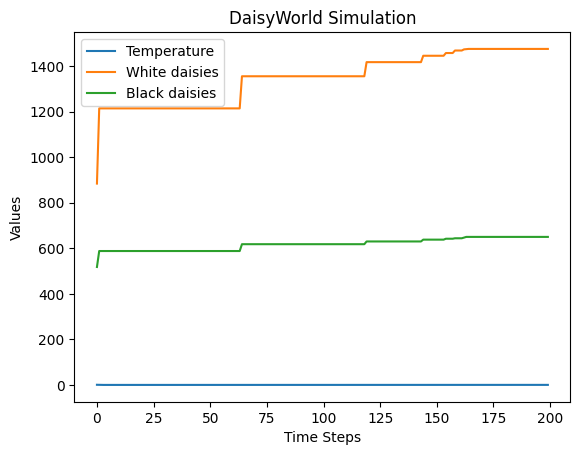

In [61]:
plt.figure

plt.plot(temperature, label="Temperature")
plt.plot(white_count, label="White daisies")
plt.plot(black_count, label="Black daisies")

plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.title("DaisyWorld Simulation")

plt.legend()
plt.show()

## Animation
------------

The animation shows how daisies spread across the grid over time.

White cells represent white daisies, while darker cells represent black daisies.
This visualization helps us understand how the system changes during the simulation.

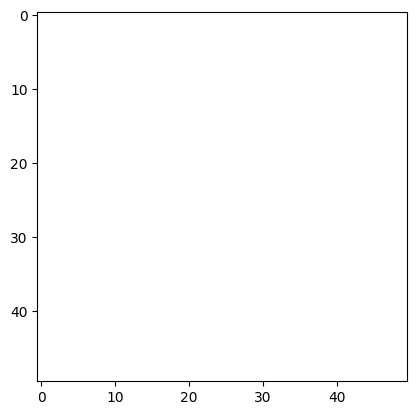

In [62]:
fig = plt.figure()
frames = []

model = DaisyWorld(50,50)

for t in range(100):
  model.step()
  img = plt.imshow(model.grid, animated=True)
  frames.append([img])

ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True)
plt.show()

## Algorithm Analysis
---------------------

### Time Complexity

At each time step, the algorithm processes every cell in the grid.

If the grid size is n × m and the simulation runs for t steps,
the total time complexity is:

O(t × n × m)

This means that increasing the grid size or the number of steps
will increase the computation time.

In [56]:
model = DaisyWorld(50,50)
time = timeit.timeit(lambda: model.step(), number=100)
print("Time for 100 steps:",time)

Time for 100 steps: 0.3619484820001162


### Efficiency Improvements

The improvements made to the algorithm do not change its overall time complexity.

The complexity remains O(t × n × m), but the implementation becomes more efficient,
which reduces the execution time in practice.

## Discussion
--------------

The Daisyworld model shows how a system can maintain balance automatically.

As solar radiation increases, white daisies grow more and reflect heat,
which helps cool the system. At the same time, black daisies decrease.

When solar radiation is lower, black daisies grow more and absorb heat,
which helps warm the system.

In my simulation, I observed that the populations of daisies change over time
and the system eventually reaches a stable state.

This idea is similar to communicable diseases, where the spread depends on interactions
between individuals and environmental conditions. When the number of infected individuals increases,
different factors can slow down the spread, similar to how daisies regulate temperature.